<a href="https://colab.research.google.com/github/shifazahra/Brugada-XGBoost-Classification/blob/main/Brugada_Syndrome_Detection_using_XGBoost_and_Advanced_Morphological_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brugada Syndrome Detection using XGBoost and Advanced Morphological**

---
Author: Salsa Anderia Putri Nabila, Shifa Fanisatuz Zahra, Najwa Shafa Azahra

Organization: Universitas Singaperbangsa Karawang (UNSIKA)

## **PART 1: Environment Setup & Data Loading**
In this section, we mount the drive, install necessary libraries (WFDB for ECG signals), and load the metadata.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install necessary libraries
!pip install wfdb PyWavelets imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.


In [3]:
# Setup Environment & Path Declaration
import os
import pandas as pd
import numpy as np
import wfdb
import pywt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Set Dataset Path
BASE_PATH = '/content/drive/MyDrive/IDSC/brugada_dataset/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0'
METADATA_PATH = os.path.join(BASE_PATH, 'metadata.csv')

# Load Metadata
if os.path.exists(METADATA_PATH):
    metadata = pd.read_csv(METADATA_PATH)
    print(f"Metadata Successfully Loaded! Total samples: {len(metadata)} patients.")
    print("\n--- Dataset Info ---")
    print(metadata.info())
    print("\n\n--- 5 First Line of Metadata ---")
    print(metadata.head())
    print("\n\n--- DESCRIPTIVE STATISTICS ---")
    print(metadata.describe())
else:
    print("Error: metadata.csv not found. Check your path.")

Metadata Successfully Loaded! Total samples: 363 patients.

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   patient_id     363 non-null    int64
 1   basal_pattern  363 non-null    int64
 2   sudden_death   363 non-null    int64
 3   brugada        363 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB
None


--- 5 First Line of Metadata ---
   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1


--- DESCRIPTIVE STATISTICS ---
         patient_id  basal_pattern  sudden_death     brugada
count  3.630000e+02     363.000000    363.000000  363.000000
mean   1.325624e+06       0.

--- CHECKING ACTUAL DATA (METADATA) ---
Total records       : 363 patients
Normal (Class 0)    : 287 patients (79.1%)
Brugada (Class 1)   : 69 patients (19.0%)


/tmp/ipykernel_2298/1144754799.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution.index, y=distribution.values, palette='Reds_r')


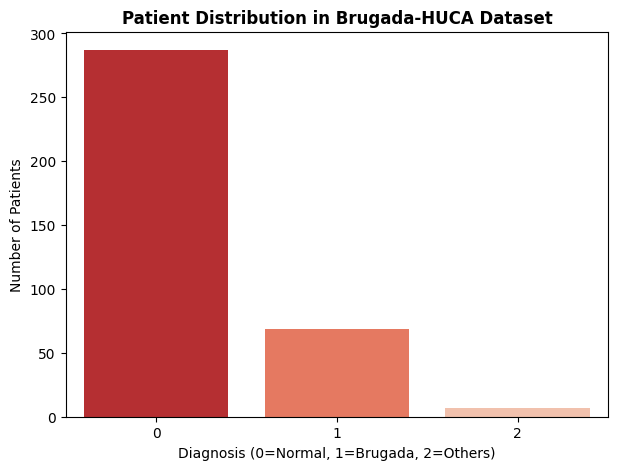

In [6]:
# Class Distribution Analysis
print("--- CHECKING ACTUAL DATA (METADATA) ---")
target_col = 'brugada'
distribution = metadata[target_col].value_counts()
total_patients = len(metadata)

print(f"Total records       : {total_patients} patients")
print(f"Normal (Class 0)    : {distribution.get(0, 0)} patients ({(distribution.get(0, 0)/total_patients)*100:.1f}%)")
print(f"Brugada (Class 1)   : {distribution.get(1, 0)} patients ({(distribution.get(1, 0)/total_patients)*100:.1f}%)")

# Visualization of Data Balance
plt.figure(figsize=(7, 5))
sns.barplot(x=distribution.index, y=distribution.values, palette='Reds_r')
plt.title('Patient Distribution in Brugada-HUCA Dataset', fontweight='bold')
plt.xlabel('Diagnosis (0=Normal, 1=Brugada, 2=Others)')
plt.ylabel('Number of Patients')
plt.show()

## **PART 2: Preprocessing & Advanced Feature Extraction**
We perform:
*   Data Cleaning: Filtering only Normal and Brugada classes.
*   Signal Transformation: Bandpass filtering (0.5-40Hz) and Robust Z-Score Normalization per patient.
*   Advanced Extraction: Calculating ST-Slope (Initial and Late) and Wavelet Energies to capture subtle Type-2/3 patterns.

In [7]:
# --- STEP 1: METADATA CLEANING ---
# We focus on Binary Classification: Normal (0) vs Brugada (1)
metadata_clean = metadata[metadata['brugada'].isin([0, 1])].copy()
metadata_clean['brugada'] = metadata_clean['brugada'].astype(int)

In [8]:
# --- STEP 2: SIGNAL PROCESSING FUNCTIONS ---
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_filter(data, lowcut=0.5, highcut=40.0, fs=100, order=2):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

def normalize_signal(data):
    # Robust Z-score normalization per patient to highlight low-amplitude patterns
    std = np.std(data)
    if std < 1e-4: return data
    return (data - np.mean(data)) / std

def is_signal_flat(segment, threshold=1e-3):
    # Data Quality Check: Detect flatlines or sensor disconnection
    return np.std(segment) < threshold

def extract_features_advanced(segment, fs=100):
    features = []
    r_idx = np.argmax(segment)
    j_idx = min(r_idx + 6, len(segment) - 1)
    st_mid_idx = min(j_idx + 5, len(segment) - 1) # 50ms after J
    st_end_idx = min(j_idx + 10, len(segment) - 1) # 100ms after J

    # 1. Clinical Morphological Features
    features.append(segment[j_idx]) # J-point amplitude

    # ST-Slope (Initial and Late slopes)
    # Crucial for differentiating Type 2/3 Saddle-back patterns
    slope_initial = segment[st_mid_idx] - segment[j_idx]
    slope_late = segment[st_end_idx] - segment[st_mid_idx]

    features.append(slope_initial)
    features.append(slope_late)
    features.append(np.trapz(segment[j_idx:st_end_idx])) # ST-segment Area
    features.append(np.max(segment) - np.min(segment)) # Peak-to-peak amplitude
    features.append(np.std(segment))

    # 2. Wavelet Features (Multiresolution Energy)
    coeffs = pywt.wavedec(segment, 'db4', level=3)
    for c in coeffs:
        features.append(np.sqrt(np.mean(np.square(c))))

    return features

In [9]:
# --- STEP 3: MAIN PROCESSING LOOP ---
def process_all_patients_v3(df_meta, base_path, fs=100):
    all_X, all_y, all_groups = [], [], []

    for idx, row in df_meta.iterrows():
        p_id = str(int(row['patient_id']))
        label = row['brugada']
        # Incorporate Clinical Metadata: Basal Pattern and Sudden Death history
        meta_features = [row['basal_pattern'], row['sudden_death']]
        record_path = os.path.join(base_path, 'files', p_id, p_id)

        try:
            record = wfdb.rdrecord(record_path)
            v1_raw = apply_filter(record.p_signal[:, record.sig_name.index('V1')])
            v2_raw = apply_filter(record.p_signal[:, record.sig_name.index('V2')])
            v5_raw = apply_filter(record.p_signal[:, record.sig_name.index('V5')])

            # Cleaner Strategy: Skip flat or corrupted signals
            if is_signal_flat(v1_raw): continue

            v1_sig, v2_sig, v5_sig = normalize_signal(v1_raw), normalize_signal(v2_raw), normalize_signal(v5_raw)
            peaks, _ = find_peaks(v1_sig, distance=60, height=0.5)

            for p in peaks:
                if 40 < p < len(v1_sig) - 60:
                    seg_v1 = v1_sig[p-40:p+60]
                    if is_signal_flat(seg_v1): continue

                    feat_v1 = extract_features_advanced(seg_v1)
                    feat_v2 = extract_features_advanced(v2_sig[p-40:p+60])

                    # Contrast Feature: Difference between V1 (diagnostic) and V5 (reference)
                    st_diff = v1_sig[p+6] - v5_sig[p+6]
                    combined_feat = meta_features + feat_v1 + feat_v2 + [st_diff]

                    all_X.append(combined_feat)
                    all_y.append(label)
                    all_groups.append(p_id)
        except: continue

    return np.array(all_X), np.array(all_y), np.array(all_groups)

# Run Feature Extraction
X, y, groups = process_all_patients_v3(metadata_clean, BASE_PATH)

/tmp/ipykernel_2298/2049634861.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  features.append(np.trapz(segment[j_idx:st_end_idx])) # ST-segment Area


## **PART 3: Modeling (Training with SMOTE & Calibration)**
In this stage, we implement GroupKFold to ensure no patient overlap between folds. We use SMOTE to balance the training set and CalibratedClassifierCV to ensure reliable probability outputs.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize GroupKFold for Patient-wise Validation
gkf = GroupKFold(n_splits=5)
all_patient_probs, all_patient_actuals, all_groups_list = [], [], []

# --- CROSS VALIDATION LOOP ---
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    g_test = groups[test_idx]

    # Handle Class Imbalance using SMOTE
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Initialize XGBoost Classifier
    base_model = XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )

    # Probability Calibration
    calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=3)
    calibrated_model.fit(X_train_res, y_train_res)

    # Inference on Original Testing Set
    y_prob = calibrated_model.predict_proba(X_test)[:, 1]

    # Aggregate results per patient (Mean Probability)
    temp_df = pd.DataFrame({'id': g_test, 'actual': y_test, 'prob': y_prob})
    patient_res = temp_df.groupby('id').agg({'actual': 'first', 'prob': 'mean'})

    all_patient_probs.extend(patient_res['prob'].values)
    all_patient_actuals.extend(patient_res['actual'].values)
    all_groups_list.extend(patient_res.index.values)

## **PART 4: Final Evaluation & Performance Analysis**
We evaluate the model using a custom medical threshold (0.35) to prioritize Recall (Sensitivity) while maintaining high Accuracy.


--- FINAL PERFORMANCE (SMOTE + CALIBRATION) Threshold: 0.35 ---
              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93       287
     Brugada       0.68      0.75      0.72        69

    accuracy                           0.88       356
   macro avg       0.81      0.83      0.82       356
weighted avg       0.89      0.88      0.89       356



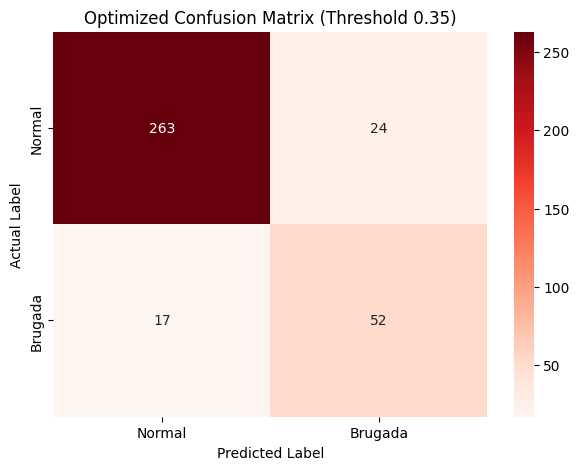

In [11]:
# Optimal Threshold for Medical Screening (Priority: High Recall)
THRESHOLD_FINAL = 0.35
final_preds = [1 if p > THRESHOLD_FINAL else 0 for p in all_patient_probs]

# Print Classification Metrics
print(f"\n--- FINAL PERFORMANCE (SMOTE + CALIBRATION) Threshold: {THRESHOLD_FINAL} ---")
print(classification_report(all_patient_actuals, final_preds, target_names=['Normal', 'Brugada']))

# Confusion Matrix Visualization
cm_optimized = confusion_matrix(all_patient_actuals, final_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Brugada'], yticklabels=['Normal', 'Brugada'])
plt.title(f'Optimized Confusion Matrix (Threshold {THRESHOLD_FINAL})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## **PART 5: Reflection & Future Work (Error Analysis)**
Identifying the 17 False Negative cases is crucial for future research. This section visualizes the signals that the model missed, providing insights into data limitations.

In [12]:
# Identify False Negative IDs
results_df = pd.DataFrame({
    'patient_id': all_groups_list,
    'actual': all_patient_actuals,
    'prob': all_patient_probs,
    'prediction': final_preds
})

fn_cases = results_df[(results_df['actual'] == 1) & (results_df['prediction'] == 0)]
fn_ids = fn_cases['patient_id'].tolist()

print(f"Detected {len(fn_ids)} False Negative patients.")
print(f"IDs of missed cases: {fn_ids}")

Detected 17 False Negative patients.
IDs of missed cases: ['1370418', '801261', '972048', '1230482', '991528', '3043155', '319150', '1199517', '1207947', '1254267', '1371554', '267630', '519687', '807363', '2187085', '3028930', '878765']


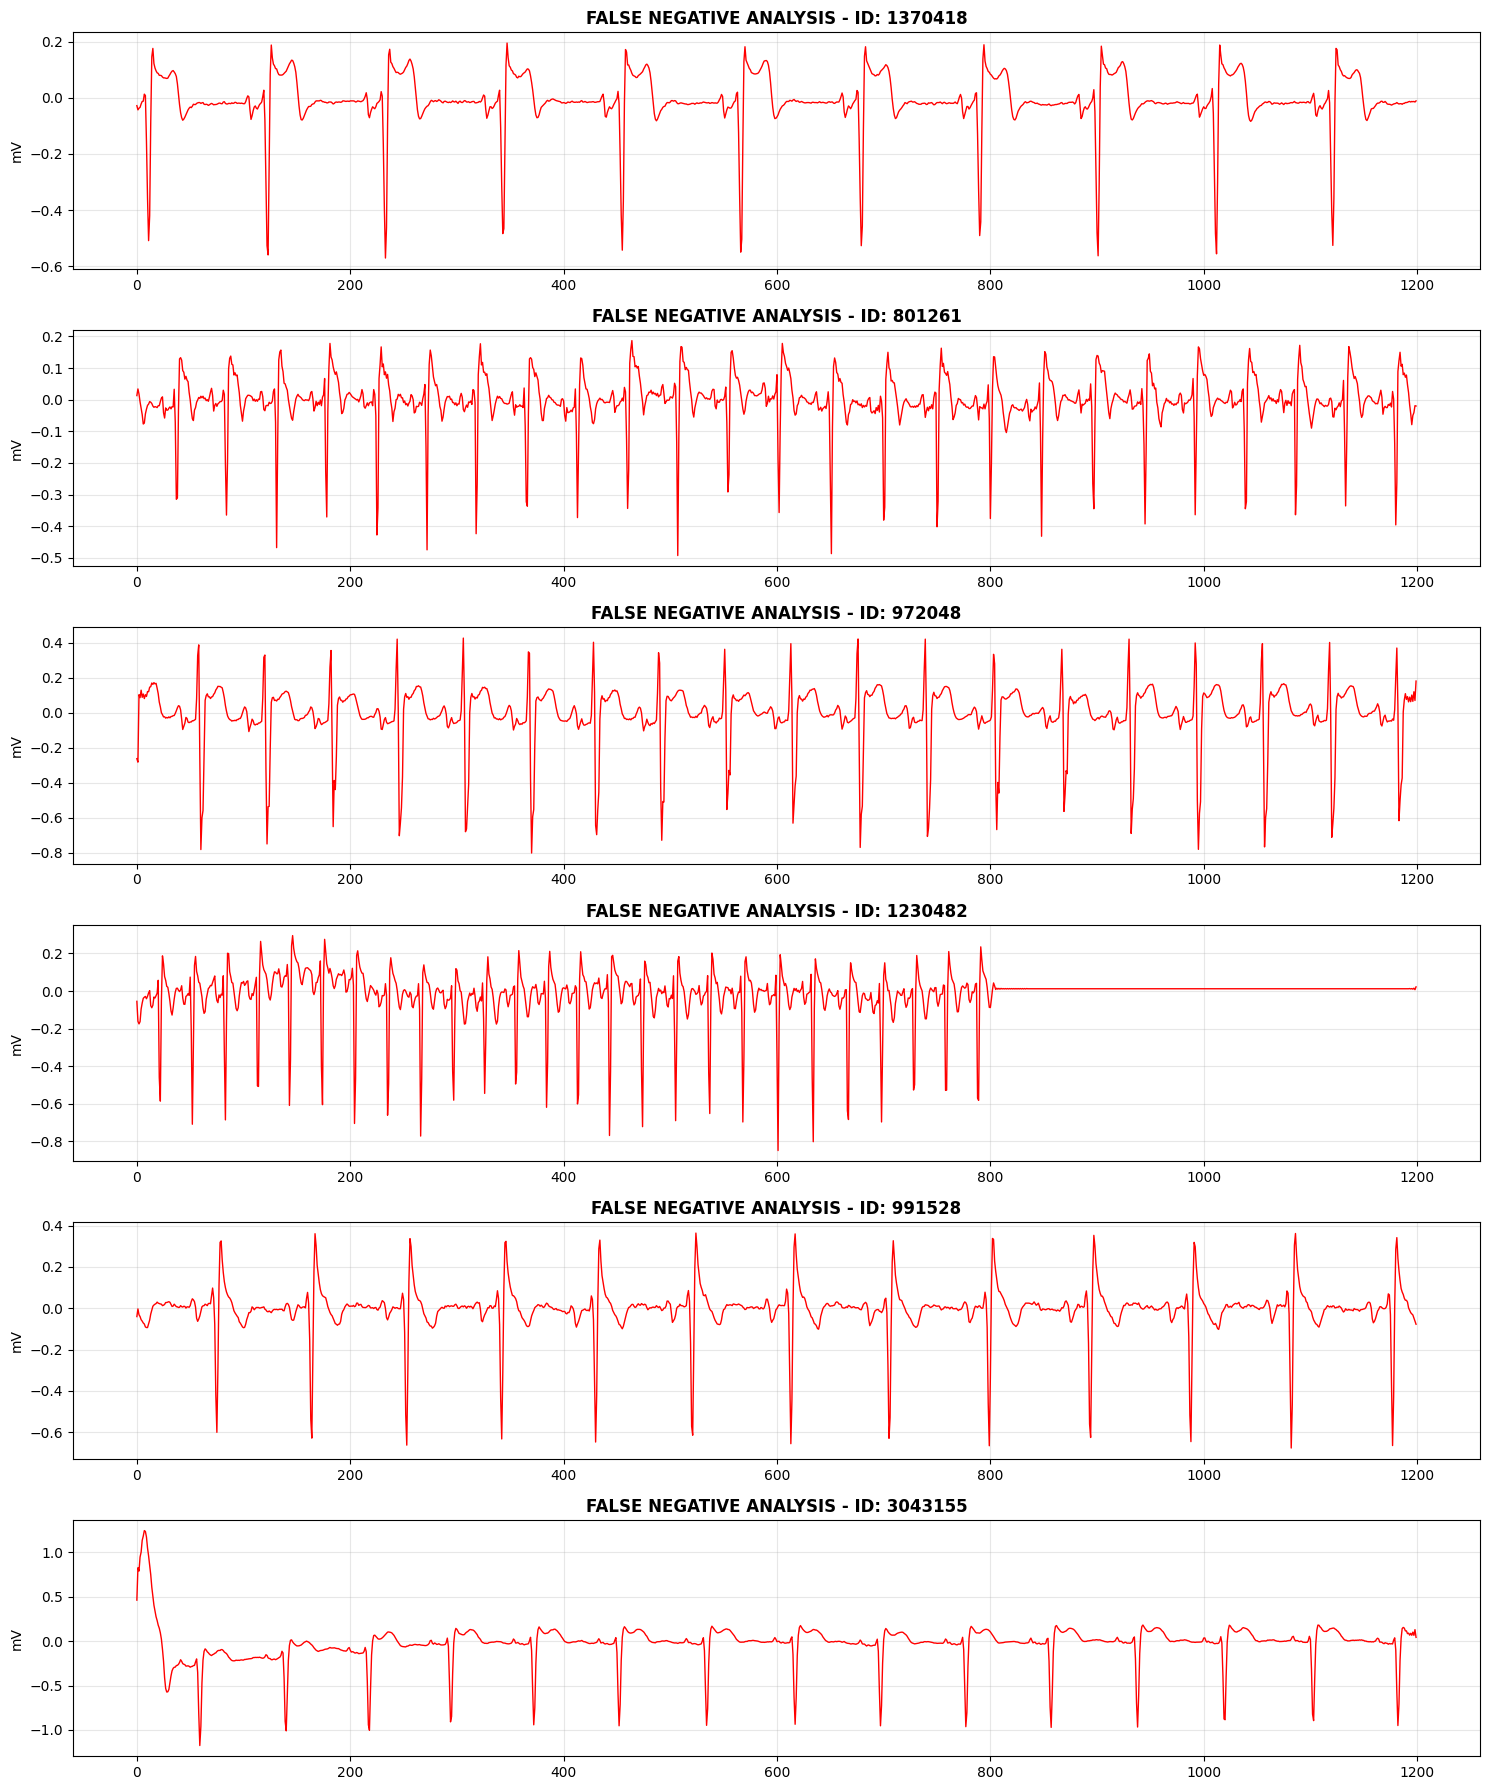

In [13]:
# Visualization of Missed Cases for Diagnostic Reflection
def plot_error_analysis(patient_list, base_path):
    num_plot = min(len(patient_list), 6)
    fig, axes = plt.subplots(num_plot, 1, figsize=(15, 3 * num_plot))

    for i in range(num_plot):
        p_id = str(int(patient_list[i]))
        record_path = os.path.join(base_path, 'files', p_id, p_id)
        record = wfdb.rdrecord(record_path)
        v1_idx = record.sig_name.index('V1')
        sig = record.p_signal[:2000, v1_idx]

        axes[i].plot(sig, color='red', linewidth=1)
        axes[i].set_title(f"FALSE NEGATIVE ANALYSIS - ID: {p_id}", fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylabel("mV")

    plt.tight_layout()
    plt.show()

plot_error_analysis(fn_ids, BASE_PATH)

After visualizing the 17 False Negative cases (Brugada patients predicted as Normal), several key insights were identified regarding why the model struggled with these specific samples:



1.   Subtle Morphological Patterns (Type 2/3):
      
      Many missed cases exhibit the "Saddle-back" pattern (Brugada Type 2 or 3). These patterns are notoriously difficult to distinguish from normal variants or Right Bundle Branch Block (RBBB) without provocative drug tests (e.g., Ajmaline challenge). The elevation in the ST-segment is so minimal that the current feature extraction threshold may classify them as within the normal physiological range.
2.   Data Quality & Technical Artifacts:

      Visual inspection revealed that certain records (e.g., ID 1230482) contained segments of "flatline" or significant signal loss. While our is_signal_flat function mitigates this, intermittent sensor disconnection or poor electrode contact can lead to "clean but weak" signals that mask the diagnostic features of Brugada Syndrome.

3.   Baseline Wander & High-Frequency Noise:

      Despite filtering, some records show residual baseline wandering or high-frequency muscle tremors. In Brugada detection, precision in the J-point and ST-slope is critical; even slight distortions in the baseline can lead the XGBoost model to underestimate the ST-segment elevation.

4.  Signal Variability:

      Brugada patterns are often intermittent. A patient might have a diagnostic ECG at one moment and a nearly normal ECG minutes later. If the 10-second recording captured in the dataset happened during a "dormant" phase, the AI—like a human cardiologist—would find it nearly impossible to detect the syndrome from that specific signal alone.

Conclusion for Future Work:

To capture these 17 remaining cases, future iterations could incorporate Deep Learning (CNN-LSTM) to detect temporal dependencies or utilize higher intercostal space lead placements, which are known to increase the sensitivity of ECG for Brugada Syndrome.